In [20]:
%load_ext autoreload
%autoreload 2

import os
# os.environ['OMP_NUM_THREADS'] = '12'

import pyttb as ttb
import numpy as np

import goated.utils.exo as ex
import goated.utils.scalers as sc
import goated.goals.physics as goals

import goated.rol_interface.models as rolm
import goated.rol_interface.objective as rolo
from goated.cp import GocchaObjective, CPGoal

from goated.cp import GocchaObjective


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# Exodus file name with tensor data
# fname = '/Volumes/phited/DrekarData/TearingMode/john_2024_08_29/output_2D_TearingMode_64x32_S_1E3.exo'
# fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/1E3_2D_TearingMode.exo'
fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/output_2D_TearingMode_64x32_S_1E3.exo'


do_goal_plots = True  # construct goal plots
save_data = False     # save tensor reconstructions to disk
save_figs = False     # save figures
rank = 15             # Rank of the CP decomposition
maxiters = 30         # max iterations of gcp_opt
pgtol = 1e-2          # BFGS tolerance

In [22]:
# Read tensor from exodus file
exo = ex.ExoInfo()
exo.read_sheet(fname)
time = exo.t
num_time = len(time)

In [23]:
# Some global parameters
vars = [0,1,3,4,6,7,9]       # Exclude BZ, R, RHO_UZ, and U
B_var_ind = [0,1]            # variable indices for magnetic field
rho_var_ind = [2]            # variable index for density
mom_var_ind = [4,5]          # variables for momentum goal
T_var_ind = [6]              # variable index for temperature
tot_var_ind = B_var_ind+rho_var_ind+mom_var_ind+T_var_ind
int_var_ind = rho_var_ind+T_var_ind
kin_var_ind = rho_var_ind+mom_var_ind
mom_time_ind = range(1,num_time)    # time steps for momenum goal (exclude first few)
energy_time_ind = range(0,num_time) # time steps for energy goals

# select subset of variables
X = ttb.tensor(exo.tensor_data[:,:,vars,:])
sz = X.shape
var_labels = [exo.var_name[v] for v in vars]

In [24]:
# scale tensor values so that each variable has roughly the same order of magnitude
scaler = sc.StdScaler(X,exo.var_mode)
Xs = scaler.scale_tensor(X)
us0,_,_ = ttb.cp_als(Xs,rank=rank,maxiters=50)
U0 = scaler.unscale_tensor(us0.full())
fit0 = 1-(X-U0).norm()/X.norm()

CP_ALS:
 Iter 0: f = 5.905230e-01 f-delta = 5.9e-01
 Iter 1: f = 7.799768e-01 f-delta = 1.9e-01
 Iter 2: f = 8.301651e-01 f-delta = 5.0e-02
 Iter 3: f = 8.547372e-01 f-delta = 2.5e-02
 Iter 4: f = 8.705217e-01 f-delta = 1.6e-02
 Iter 5: f = 8.782243e-01 f-delta = 7.7e-03
 Iter 6: f = 8.826172e-01 f-delta = 4.4e-03
 Iter 7: f = 8.856061e-01 f-delta = 3.0e-03
 Iter 8: f = 8.879372e-01 f-delta = 2.3e-03
 Iter 9: f = 8.900731e-01 f-delta = 2.1e-03
 Iter 10: f = 8.925996e-01 f-delta = 2.5e-03
 Iter 11: f = 8.963495e-01 f-delta = 3.7e-03
 Iter 12: f = 9.001114e-01 f-delta = 3.8e-03
 Iter 13: f = 9.025294e-01 f-delta = 2.4e-03
 Iter 14: f = 9.043891e-01 f-delta = 1.9e-03
 Iter 15: f = 9.064528e-01 f-delta = 2.1e-03
 Iter 16: f = 9.107509e-01 f-delta = 4.3e-03
 Iter 17: f = 9.190196e-01 f-delta = 8.3e-03
 Iter 18: f = 9.232974e-01 f-delta = 4.3e-03
 Iter 19: f = 9.252516e-01 f-delta = 2.0e-03
 Iter 20: f = 9.265898e-01 f-delta = 1.3e-03
 Iter 21: f = 9.276716e-01 f-delta = 1.1e-03
 Iter 22: f 

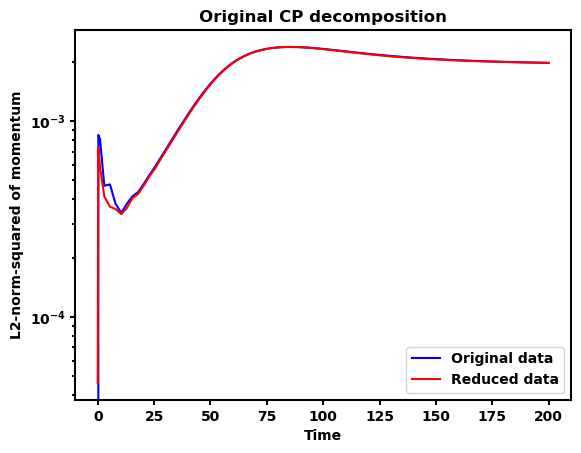

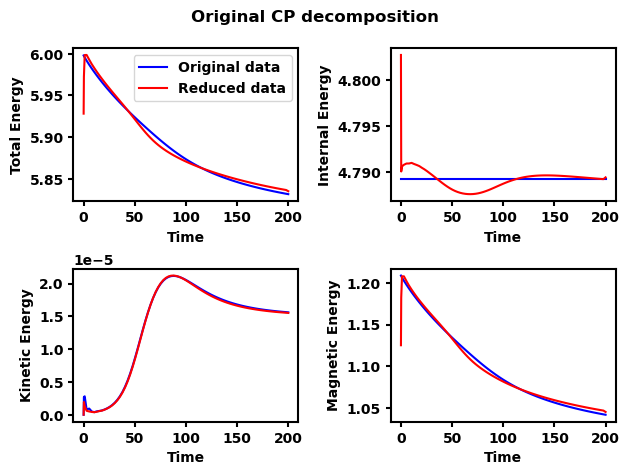

In [25]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us0,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('mom-initial.png')

    fig,axs = goals.plot_energies(X,us0,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('energy-initial.png')

In [26]:
mom_goal = goals.MomentumGoal(X,mom_var_ind,mom_time_ind,exo)
E_goal = goals.TotalEnergyGoal(X,tot_var_ind,energy_time_ind,exo)
T_goal = goals.InternalEnergyGoal(X,int_var_ind,energy_time_ind,exo)
P_goal = goals.KineticEnergyGoal(X,kin_var_ind,energy_time_ind,exo)
B_goal = goals.MagneticEnergyGoal(X,B_var_ind,energy_time_ind,exo)

mom_goal0 = mom_goal.computeValue(U0)
E_goal0 = E_goal.computeValue(U0)
T_goal0 = T_goal.computeValue(U0)
P_goal0 = P_goal.computeValue(U0)
B_goal0 = B_goal.computeValue(U0)

print(f'Initial fit = {fit0:.4f}, momentum goal = {mom_goal0:.2e}, total energy goal = {E_goal0:.2e}, internal energy goal = {T_goal0:.2e}, kinetic energy goal {P_goal0:.2e}, magnetic energy goal = {B_goal0:.2e}')

Initial fit = 0.9974, momentum goal = 8.69e-08, total energy goal = 6.92e-03, internal energy goal = 2.50e-04, kinetic energy goal 4.36e-12, magnetic energy goal = 8.57e-03


In [27]:
my_goals = [mom_goal,T_goal,P_goal,B_goal]
ng = len(my_goals)+1
weights = [1/(ng*mom_goal0),1/(ng*T_goal0),1/(ng*P_goal0),1/(ng*B_goal0)]
goal = CPGoal(scaler, my_goals, weights)
a = 1/(ng*((Xs-us0.full()).norm()**2))
cp = GocchaObjective(Xs, goal, a, 1.0)
_ = us0.normalize(weight_factor='all')

precondition = True
goccha = GocchaObjective(precondition, cp, a, 1.0)
rol_params = rolm.build_parameter_list()
problem = rolm.GocchaRolModel(goccha, us0)
problem.solve(rol_params, precondition=precondition)



Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.323180e+02   2.548732e+01   ---            1.000000e+01   1         1         ---       ---       ---       
  1     1.310489e+02   2.656457e+01   1.000000e+01   2.500000e+01   2         2         0         2         3         
  2     1.277326e+02   3.183729e+01   2.500000e+01   6.250000e+01   3         3         0         3         3         
  3     1.216808e+02   3.944633e+01   6.250000e+01   1.562500e+02   4         4         0         4         3         
  4     1.111010e+02   6.535012e+01   1.562500e+02   3.906250e+02   5         5         0         6         3         
  5     1.111010e+02   6.535012e+01   3.906250e+02   2.441406e+01   6         5         2         19        3         
  6     1.066058e+02   1.150752e+01   2.441406e+01   6.103516e+01   7         6         0         6         3         
  7     1.0383

In [28]:
us1 = problem.decomp
U1 = scaler.unscale_tensor(us1.full())
fit1 = 1-(X-U1).norm()/X.norm()
mom_goal1 = mom_goal.computeValue(U1)
E_goal1 = E_goal.computeValue(U1)
T_goal1 = T_goal.computeValue(U1)
P_goal1 = P_goal.computeValue(U1)
B_goal1 = B_goal.computeValue(U1)

print(f'Final fit = {fit1:.4f}, momentum goal = {mom_goal1:.2e}, total energy goal = {E_goal1:.2e}, internal energy goal = {T_goal1:.2e}, kinetic energy goal {P_goal1:.2e}, magnetic energy goal = {B_goal1:.2e}')

Final fit = 0.9815, momentum goal = 5.91e-08, total energy goal = 3.26e-03, internal energy goal = 1.17e-04, kinetic energy goal 1.04e-11, magnetic energy goal = 3.29e-03


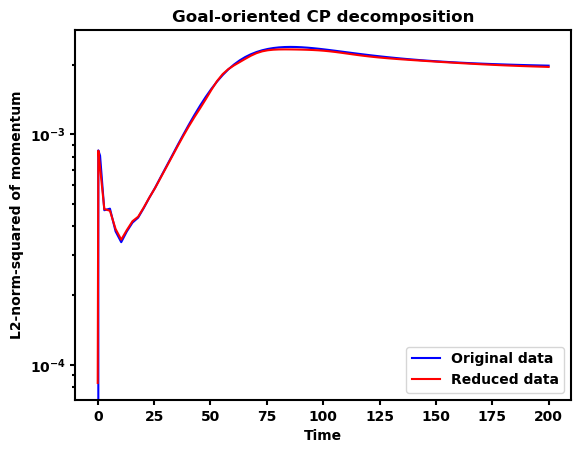

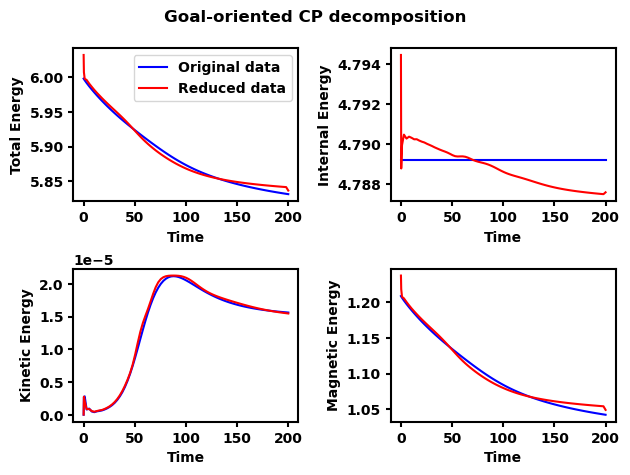

In [29]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us1,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('mom-final.png')

    fig,axs = goals.plot_energies(X,us1,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('energy-final.png')